# Parte 3: Modelo A vs. Modelo B

## Comparacao e Recomendacao

**Objetivo**: Comparar o modelo A com o modelo B e recomendar, com base em evidencias estatisticas, se devemos ou nao substituir o modelo atual.

In [1]:
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import chi2

from sklearn.metrics import balanced_accuracy_score, classification_report
from sklearn.calibration import calibration_curve
from statsmodels.stats.contingency_tables import mcnemar
from statsmodels.stats.contingency_tables import SquareTable
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
)

DADOS_PATH = Path('../dados/chamados_com_predicoes.csv')
FIGURES_PATH = Path('../results/figures/')

In [2]:
cat_map = {
    "iluminacao_publica": "Iluminação Pública",
    "buraco_via": "Buraco em Via",
    "coleta_lixo": "Coleta de Lixo",
    "esgoto_vazamento": "Vazamento de Esgoto",
    "poda_arvore": "Poda de Árvore",
    "estacionamento_irregular": "Estacionamento Irregular",
    "barulho_perturbacao": "Barulho / Perturbação",
    "sinalizacao": "Sinalização",
}

## 4. Devemos Trocar de Modelo?

In [3]:
df = pd.read_csv(DADOS_PATH, encoding="utf-8")
df["data_abertura"] = pd.to_datetime(df["data_abertura"])

categorias = sorted(df["categoria_real"].unique())

In [4]:
y_true = df["categoria_real"]
y_pred_a = df["pred_modelo_a"]
y_pred_b = df["pred_modelo_b"]

a_certo = (y_pred_a == y_true)
b_certo = (y_pred_b == y_true)

n11 = (a_certo & b_certo).sum()  # ambos certos
n10 = (a_certo & ~b_certo).sum()  # A certo, B errado
n01 = (~a_certo & b_certo).sum()  # A errado, B certo
n00 = (~a_certo & ~b_certo).sum()  # ambos errados

In [5]:
# Teste McNemar
table = [
    [n11, n10],
    [n01, n00]
]

resultado = mcnemar(
    table,
    exact=False,
    correction=True
)

print(f"Estatística: {resultado.statistic:.4f}")
print(f"p-valor: {resultado.pvalue:.6f}")

Estatística: 148.3614
p-valor: 0.000000


#### Teste de McNemar

Como os dois modelos foram avaliados sobre os mesmos 5.000 chamados, as predições são pareadas. Inicialmente foi escolhido o teste de McNemar, porque é adequado para comparar dois classificadores avaliados sobre o mesmo conjunto de exemplos. Considerando apenas os casos discordantes:

**Hipóteses**

- **Hipótese nula (H0)**: os dois modelos têm a mesma probabilidade de acerto.
- **Hipótese alternativa (H1)**: os dois modelos têm probabilidades de acerto diferentes.

Como o p-valor deu um valor menor que < 0,05 indica evidência estatística muito forte contra a hipótese, ou seja, rejeitamos a hipótese de que ambos os modelos têm a mesma probabilidade de acerto. 

In [6]:
print(f'Casos onde A acertou e B errou: {n10}')
print(f'Casos onde A errou e B acertou: {n01}')
print(f'Diferença líquida a favor de B: {n01 - n10}')

Casos onde A acertou e B errou: 517
Casos onde A errou e B acertou: 991
Diferença líquida a favor de B: 474


In [7]:
def metricas_globais(y_true, y_pred):
    return {
        "Acurácia": accuracy_score(y_true, y_pred),
        "F1 Macro": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "F1 Weighted": f1_score(y_true, y_pred, average="weighted", zero_division=0),
    }

metricas_a = metricas_globais(y_true, y_pred_a)
metricas_b = metricas_globais(y_true, y_pred_b)

comparacao_global = pd.DataFrame({
    "Modelo A": metricas_a,
    "Modelo B": metricas_b,
})
comparacao_global["Diferença (B - A)"] = (
        comparacao_global["Modelo B"] - comparacao_global["Modelo A"]
)

display(comparacao_global.style.format("{:.3f}"))

,Modelo A,Modelo B,Diferença (B - A)
Acurácia,0.773,0.868,0.095
F1 Macro,0.770,0.852,0.081
F1 Weighted,0.773,0.864,0.091


O Modelo B apresenta desempenho global superior ao Modelo A.

A acurácia balanceada aumenta de aproximadamente 77% para 87%, o que representa um ganho de cerca de 10 pontos percentuais. Além disso, o F1 macro também melhora, indicando que o ganho não ocorre apenas por causa das categorias mais frequentes. Apesar disso, há uma troca relativamente consideravel entre erros do modela A para o modelo B, sendo 474 a favor do modelo B.

### 4.1. Comparação por Categoria

In [8]:
tabela = pd.crosstab(y_pred_a, y_pred_b)

# Teste de Stuart–Maxwell
resultado = SquareTable(tabela).homogeneity()
print(resultado)

df          7
pvalue      0.0
statistic   128.18420372297822


Como o problema é multiclasse, também foi avaliado se os modelos distribuem suas predições da mesma forma entre as categorias.

Para isso, foi aplicado o teste de Stuart-Maxwell (generalização do teste de McNemar) sobre a tabela pareada de predições dos modelos.

O resultado rejeita a hipótese de homogeneidade marginal, indicando que os modelos não distribuem suas previsões da mesma forma entre as categorias. Esse resultado reforça que a comparação global deve ser complementada por uma análise por categoria.


In [9]:
print("Modelo A")
print(classification_report(y_true, y_pred_a))

print("Modelo B")
print(classification_report(y_true, y_pred_b))

Modelo A
                          precision    recall  f1-score   support

     barulho_perturbacao       0.80      0.78      0.79       400
              buraco_via       0.66      0.82      0.73       908
             coleta_lixo       0.81      0.81      0.81       806
        esgoto_vazamento       0.71      0.58      0.64       621
estacionamento_irregular       0.80      0.83      0.81       437
      iluminacao_publica       0.86      0.79      0.82      1143
             poda_arvore       0.80      0.78      0.79       458
             sinalizacao       0.74      0.80      0.77       227

                accuracy                           0.77      5000
               macro avg       0.77      0.77      0.77      5000
            weighted avg       0.78      0.77      0.77      5000

Modelo B
                          precision    recall  f1-score   support

     barulho_perturbacao       0.85      0.88      0.86       400
              buraco_via       0.87      0.92      0.8

In [10]:
resultados = []

for cat, df_cat in df.groupby("categoria_real"):

    y_true_cat = df_cat["categoria_real"]
    y_pred_cat_a = df_cat["pred_modelo_a"]
    y_pred_cat_b = df_cat["pred_modelo_b"]

    a_certo_cat = (y_pred_cat_a == y_true_cat)
    b_certo_cat = (y_pred_cat_b == y_true_cat)

    n11 = (a_certo_cat & b_certo_cat).sum()
    n10 = (a_certo_cat & ~b_certo_cat).sum()
    n01 = (~a_certo_cat & b_certo_cat).sum()
    n00 = (~a_certo_cat & ~b_certo_cat).sum()

    table = [[n11, n10],
             [n01, n00]]

    resultado = mcnemar(
        table,
        exact=False,
        correction=True
    )

    estatistica = resultado.statistic
    pvalor = resultado.pvalue

    resultados.append({
        "Categoria": cat,
        "N": len(df_cat),
        "Acc_A": a_certo_cat.mean(),
        "Acc_B": b_certo_cat.mean(),
        "n10": n10,
        "n01": n01,
        "Diferença": a_certo_cat.mean() - b_certo_cat.mean(),
        "p-valor": pvalor
    })

resultado_categoria = pd.DataFrame(resultados)
resultado_categoria

,Categoria,N,Acc_A,Acc_B,n10,n01,Diferença,p-valor
0,barulho_perturbacao,400,0.775000,0.880000,32,74,-0.105000,6.825959e-05
1,buraco_via,908,0.817181,0.917401,64,155,-0.100220,1.189621e-09
2,coleta_lixo,806,0.806452,0.916873,53,142,-0.110422,2.941880e-10
3,esgoto_vazamento,621,0.578100,0.888889,47,240,-0.310789,8.965387e-30
4,estacionamento_irregular,437,0.826087,0.897025,39,70,-0.070938,4.059783e-03
5,iluminacao_publica,1143,0.792651,0.897638,93,213,-0.104987,1.026213e-11
6,poda_arvore,458,0.775109,0.526201,167,53,0.248908,2.567231e-14
7,sinalizacao,227,0.797357,0.894273,22,44,-0.096916,9.740122e-03


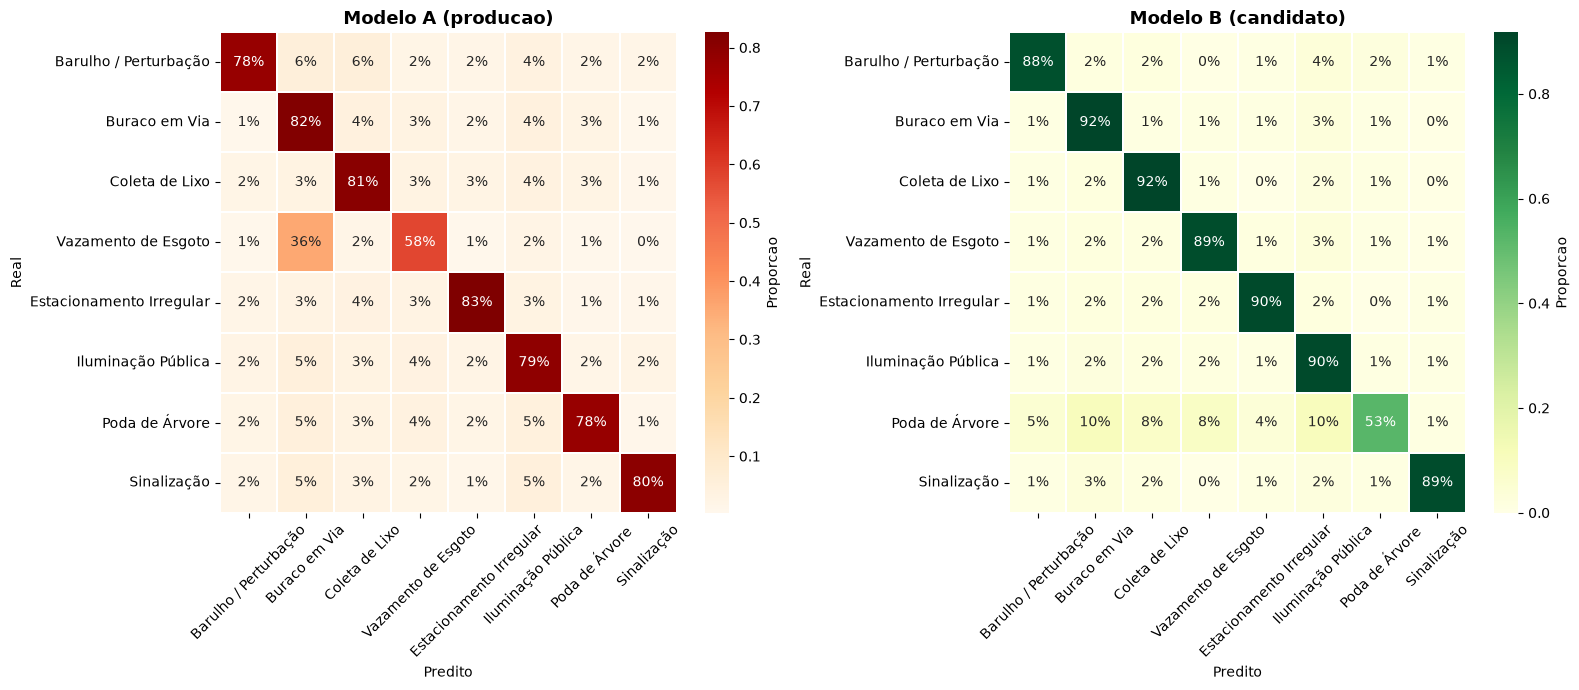

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

for ax_idx, (y_pred, titulo, cmap) in enumerate([
    (y_pred_a, 'Modelo A (producao)', 'OrRd'),
    (y_pred_b, 'Modelo B (candidato)', 'YlGn')
]):
    cm = confusion_matrix(y_true, y_pred, labels=categorias)
    cm_norm = cm.astype('float') / cm.sum(axis=1, keepdims=True)

    sns.heatmap(cm_norm, annot=True, fmt='.0%', cmap=cmap,
                xticklabels=[cat_map[c] for c in categorias],
                yticklabels=[cat_map[c] for c in categorias],
                ax=axes[ax_idx], linewidths=0.3, cbar_kws={'label': 'Proporcao'})
    axes[ax_idx].set_title(titulo, fontweight='bold', fontsize=13)
    axes[ax_idx].set_xlabel('Predito')
    axes[ax_idx].set_ylabel('Real')
    axes[ax_idx].tick_params(axis='x', rotation=45)
    axes[ax_idx].tick_params(axis='y', rotation=0)

plt.tight_layout()
plt.savefig(FIGURES_PATH / 'matrizes_confusao_comparacao.png', dpi=150, bbox_inches='tight')
plt.show()

A melhora global do Modelo B se sustenta na maioria das categorias.

O Modelo B melhora em:

- **Barulho / Perturbação**;
- **Buraco em Via**;
- **Coleta de Lixo**;
- **Vazamento de Esgoto**;
- **Estacionamento Irregular**;
- **Iluminação Pública**;
- **Sinalização**.

O ganho mais importante ocorre em **Vazamento de Esgoto**, justamente a categoria mais problemática para o Modelo A.

Esse é um ganho operacional relevante, pois reduz falhas em uma categoria com potencial impacto sanitário e necessidade de encaminhamento especializado. A perda no entanto acaba ocorrendo na categoria de `Poda de Árvore` que em termos práticos é uma demanda de menor necessidade, geralmente preventiva, mas que pode ser elevada para urgente se houver risco iminente de queda.

### 4.2. Análise da Confiança

In [12]:
def calculate_ece(y_true, y_pred, confidence, n_bins=10):
    correct = (y_true == y_pred).astype(int)
    bins = np.linspace(0, 1, n_bins + 1)
    ece = 0

    for i in range(n_bins):
        mask = (
            (confidence >= bins[i]) &
            (confidence < bins[i + 1])
        )
        
        if mask.sum() == 0:
            continue
        acc = correct[mask].mean()
        conf = confidence[mask].mean()
        ece += (mask.sum() / len(confidence)) * abs(acc - conf)

    return ece

In [13]:
ece_a = calculate_ece(
    df["categoria_real"],
    df["pred_modelo_a"],
    df["conf_modelo_a"]
)

ece_b = calculate_ece(
    df["categoria_real"],
    df["pred_modelo_b"],
    df["conf_modelo_b"]
)

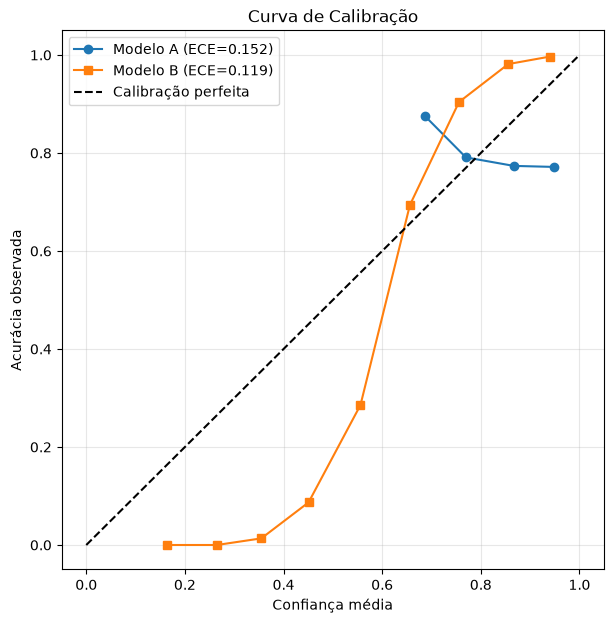

In [14]:
y_a = (df["pred_modelo_a"] == df["categoria_real"]).astype(int)
y_b = (df["pred_modelo_b"] == df["categoria_real"]).astype(int)

prob_a = df["conf_modelo_a"]
prob_b = df["conf_modelo_b"]

acc_a, conf_a = calibration_curve(
    y_a,
    prob_a,
    n_bins=10,
    strategy="uniform"
)

acc_b, conf_b = calibration_curve(
    y_b,
    prob_b,
    n_bins=10,
    strategy="uniform"
)

plt.figure(figsize=(7,7))

plt.plot(
    conf_a,
    acc_a,
    marker="o",
    label=f"Modelo A (ECE={ece_a:.3f})"
)

plt.plot(
    conf_b,
    acc_b,
    marker="s",
    label=f"Modelo B (ECE={ece_b:.3f})"
)

plt.plot([0,1], [0,1], "--", color="black", label="Calibração perfeita")

plt.xlabel("Confiança média")
plt.ylabel("Acurácia observada")
plt.title("Curva de Calibração")
plt.legend()
plt.grid(alpha=0.3)
plt.savefig(FIGURES_PATH / 'curva_calibracao.png', dpi=150, bbox_inches='tight')
plt.show()

A auditoria mostrou que o Modelo A comete muitos erros mesmo com confiança alta, dessa forma qualquer uso da confiança como critério de automação deve ser acompanhado de monitoramento contínuo, análise de calibração, e revisão humana. Por outro lado o modelo B, se mostrou mais estável nesse sentido, favorecendo ainda mais o uso do Modelo B.

## Resultados e Conclusão

Conforme as análises acima, o modelo B se mostrou superior em quase todas as métricas, tendo como seu principal trade-off na troca do modelo A para o B é piora de forma relevante na categoria `Poda de Árvore`. No qual o Modelo B deixa de identificar corretamente uma parcela maior dos chamados reais de Poda de Árvore. 

Sendo os possíveis impactos:
- aumento de retrabalho nessa categoria;
- atraso no atendimento de demandas relacionadas a árvores, galhos, queda ou risco em via pública.

Como é uma categoria relevante, é necessário algumas medidas de mitigação, a fim de evitar problemas maiores, como:
- Monitoramento específico de Poda de Árvore e Revisão humana de chamados com indícios.
- Plano de correção


## Recomendação

Recomenda-se substituir o Modelo A pelo Modelo B, pois o novo modelo reduz de forma relevante a quantidade de chamados encaminhados incorretamente. Na base avaliada, o Modelo B aumentou a taxa de acerto de cerca de 77% para 87% e corrigiu mais erros do modelo atual do que criou novos erros. A principal vantagem aparece em categorias importantes como Vazamento de Esgoto, que tinha desempenho fraco no modelo atual. O principal risco da troca está em Poda de Árvore, categoria na qual o Modelo B piora a identificação dos chamados. Por isso, a troca deve ser feita com monitoramento específico dessa categoria, revisão humana temporária para casos suspeitos e acompanhamento das métricas nas primeiras semanas de uso.